In [1]:
import pandas as pd
h=pd.read_csv("Housing.csv")
h

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [2]:
h.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [3]:
h.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [4]:
h.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
h.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
h1=pd.get_dummies(h,columns=["mainroad"],drop_first=True)
h1

,price,area,bedrooms,bathrooms,stories,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,mainroad_yes
0,13300000,7420,4,2,3,no,no,no,yes,2,yes,furnished,True
1,12250000,8960,4,4,4,no,no,no,yes,3,no,furnished,True
2,12250000,9960,3,2,2,no,yes,no,no,2,yes,semi-furnished,True
3,12215000,7500,4,2,2,no,yes,no,yes,3,yes,furnished,True
4,11410000,7420,4,1,2,yes,yes,no,yes,2,no,furnished,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,no,yes,no,no,2,no,unfurnished,True
541,1767150,2400,3,1,1,no,no,no,no,0,no,semi-furnished,False
542,1750000,3620,2,1,1,no,no,no,no,0,no,unfurnished,True
543,1750000,2910,3,1,1,no,no,no,no,0,no,furnished,False


In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
le=LabelEncoder()
h["guestroom"]=le.fit_transform(h["guestroom"])
h

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,0,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,0,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,0,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,0,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,1,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,0,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,0,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,0,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,0,no,no,no,0,no,furnished


In [9]:
x=h[['area','bedrooms','bathrooms']]
y=h['price']

In [10]:
x

,area,bedrooms,bathrooms
0,7420,4,2
1,8960,4,4
2,9960,3,2
3,7500,4,2
4,7420,4,1
...,...,...,...
540,3000,2,1
541,2400,3,1
542,3620,2,1
543,2910,3,1


In [11]:
y

0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
x_train

,area,bedrooms,bathrooms
542,3620,2,1
496,4000,2,1
484,3040,2,1
507,3600,2,1
252,9860,3,1
...,...,...,...
70,4000,3,2
277,10360,2,1
9,5750,3,2
359,3600,3,1


In [14]:
x_test  

,area,bedrooms,bathrooms
239,4000,3,1
113,9620,3,1
325,3460,4,1
66,13200,2,1
479,3660,4,1
...,...,...,...
76,6420,3,2
132,5200,3,1
311,6060,2,1
464,4500,2,1


In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 391.4 , 474566.09,1415259.95]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['area','bedrooms','bathrooms']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.552e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [17]:
y_pred=model.predict(x_test)
y_pred

array([ 3949389.22619793,  6149057.11813487,  4212599.32744967,
        7075702.95842909,  4290879.32360401,  6284439.12672419,
        3890679.22908218,  3745861.23619665,  3283819.94471289,
        7796215.16663764,  6622015.22432255,  3933733.22696706,
        3734119.2367735 ,  4755673.18658763,  4726318.18802975,
        3334891.25638637,  3827083.11802401,  4740017.18735676,
        3597129.2435034 ,  3670523.12571533,  6988959.09211324,
        6323579.12480136,  4340789.20696963,  3049169.27042303,
        4896577.17966544,  5031959.18825476,  5123589.16851302,
        4606941.19389438,  6505929.13108328,  4896577.17966544,
        3631383.12763816,  3274224.25936675,  5671549.1415934 ,
        3490479.13456035,  3604957.24311884,  4429839.08841242,
        5206755.27860978,  3572079.64473402,  2784987.05503659,
        3235084.26128958,  7125949.08538334,  6582875.22624538,
        6069169.13729975,  4534532.19745162,  3761517.23542752,
        6147449.13345409,  4012013.22312

In [18]:
y_test

239    4585000
113    6083000
325    4007500
66     6930000
479    2940000
        ...   
76     6650000
132    5810000
311    4123000
464    3080000
155    5530000
Name: price, Length: 109, dtype: int64

In [19]:
x_train

,area,bedrooms,bathrooms
542,3620,2,1
496,4000,2,1
484,3040,2,1
507,3600,2,1
252,9860,3,1
...,...,...,...
70,4000,3,2
277,10360,2,1
9,5750,3,2
359,3600,3,1


In [20]:
x_test

,area,bedrooms,bathrooms
239,4000,3,1
113,9620,3,1
325,3460,4,1
66,13200,2,1
479,3660,4,1
...,...,...,...
76,6420,3,2
132,5200,3,1
311,6060,2,1
464,4500,2,1


In [21]:
import numpy as np
ny=model.predict(np.array([7000,4,2]).reshape(-1,3))
ny

C:\Users\gavas\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([7013415.20509424])

In [22]:
a=np.array([[1,2,3,46],[2,5,8,0]])

In [23]:
a

array([[ 1,  2,  3, 46],
       [ 2,  5,  8,  0]])

In [24]:
a.reshape(-1,2)

array([[ 1,  2],
       [ 3, 46],
       [ 2,  5],
       [ 8,  0]])

In [25]:
import matplotlib.pyplot as plt

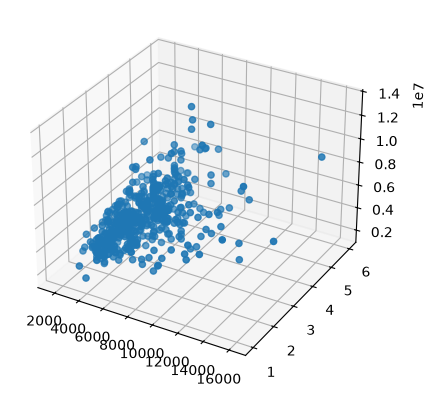

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(x["area"],x["bedrooms"],y)
plt.show()